2D structured grid verification 
- uniform inviscid flow 
- with inlet and outlet boundary conditions
- with slip and noslip wall boundary conditions

Test cases
- Case 1 – No BC                      → zero eigenvalues expected (neutral modes)
- Case 2 – Riemann inlet/outlet + slip walls   → all eigenvalues positive (BC absorbed zero modes)
- Case 3 – Riemann inlet/outlet + no-slip walls → all eigenvalues positive

v4 modify boundary flux jacobian
- updated ghost_state_jacobian fd to relative eps
- updated viscous_flux_jacobian to relative eps

APPLY assemble_global_flux_jacobian_fdv2

In [23]:
import numpy as np
import sympy as sp
from pyau3d.utils import PltFileUtils, GrpFileUtils, UnkFileUtils
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import pandas as pd
import jax
import jax.numpy as jnp

from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigs
from scipy.io import mmwrite, mmread


In [24]:
# =============================================================================
# GLOBAL FLUX JACOBIAN ASSEMBLER — FINITE DIFFERENCE VERSION (v4)
# Self-contained: all dependencies included.
#
# Updates from v1:
#   (1) viscous_flux_jacobians_fd   — relative eps scaling  (default eps_visc  = 1e-8)
#   (2) ghost_state_jacobian_fd     — relative eps scaling  (default eps_ghost = 1e-6)
#   (3) boundary_flux_jacobian_fd   — exact non-frozen ghost chain rule:
#                                     J_bc = A⁺ + A⁻ @ dUg/dUi  (riemann)
#   (4) assemble_global_jacobian_fd — both eps values exposed in signature
#
# Updates from v2:
#   (5) slip_wall_flux_jacobian     — exact analytic BC Jacobian (replaces FD/Roe):
#                                     J_bc = dF/dV|_W @ dV/dU
#                                     F_W = [0, P·nx, P·ny, P·nz, 0]ᵀ  (u_n = 0)
#   (6) dV_dU                       — primitive/conservative Jacobian (5×5, 3D)
#   (7) assemble_global_jacobian_fd — Area scaling applied to all face contributions
#                                     (fixes factor-of-2 error at corner BC nodes)
#
# Updates from v3:
#   (8) boundary_flux_jacobian_fd   — no-slip wall: non-frozen ghost chain rule:
#                                     J_bc = dFv/dUi + dFv/dUg @ dUg/dUi
#                                     dUg/dUi = diag([1,−1,−1,−1,1])  (exact, no FD)
#   (9) extract_cell_volumes        — two-pass volume extraction: col 5 for i-nodes,
#                                     geometric dual-mesh fallback for j-only nodes
#  (10) assemble_global_jacobian_fd — volume normalisation now internal:
#                                     J_phys = diag(1/Vol) @ J_raw  → [1/s]
#                                     controlled by normalise_volume=True (default)
#
# To tune eps, change only the two arguments in assemble_global_jacobian_fd:
#     eps_visc       : FD step for viscous flux Jacobian          (default 1e-8)
#     eps_ghost      : FD step for Riemann ghost state Jacobian   (default 1e-6)
#     normalise_volume : divide rows by cell volume before return (default True)
# =============================================================================

import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse import diags


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — Inviscid flux Jacobian building blocks
# ─────────────────────────────────────────────────────────────────────────────

def compute_dFdU(U, normal, gamma=1.4):
    """Inviscid flux Jacobian dF/dU at state U in direction normal."""
    rho  = U[0]
    rho_u, rho_v, rho_w, rho_E = U[1], U[2], U[3], U[4]
    nx, ny, nz = normal[0], normal[1], normal[2]
    u = rho_u / rho;  v = rho_v / rho;  w = rho_w / rho
    E = rho_E / rho
    phi = 0.5*(gamma - 1.0)*(u**2 + v**2 + w**2)
    V   = nx*u + ny*v + nz*w
    a1  = gamma*E - phi
    a2  = gamma - 1.0
    a3  = gamma - 2.0
    A   = np.zeros((5, 5))
    A[0, 1] = nx;   A[0, 2] = ny;   A[0, 3] = nz
    A[1, 0] = nx*phi - u*V
    A[1, 1] = V - a3*nx*u;  A[1, 2] = ny*u - a2*nx*v;  A[1, 3] = nz*u - a2*nx*w;  A[1, 4] = a2*nx
    A[2, 0] = ny*phi - v*V
    A[2, 1] = nx*v - a2*ny*u;  A[2, 2] = V - a3*ny*v;  A[2, 3] = nz*v - a2*ny*w;  A[2, 4] = a2*ny
    A[3, 0] = nz*phi - w*V
    A[3, 1] = nx*w - a2*nz*u;  A[3, 2] = ny*w - a2*nz*v;  A[3, 3] = V - a3*nz*w;  A[3, 4] = a2*nz
    A[4, 0] = V*(phi - a1)
    A[4, 1] = a1*nx - a2*u*V;  A[4, 2] = a1*ny - a2*v*V;  A[4, 3] = a1*nz - a2*w*V;  A[4, 4] = gamma*V
    return A


def absolute_normal_jacobian(U, n, gamma=1.4):
    """Absolute-value normal Jacobian |A_n| (eqs. 3.6.16–3.6.26)."""
    U = np.asarray(U, dtype=float)
    n = np.asarray(n, dtype=float);  n = n / np.linalg.norm(n)
    rho = U[0];  vel = U[1:4] / rho;  E = U[4] / rho
    q2  = np.dot(vel, vel)
    p   = (gamma - 1.0)*rho*(E - 0.5*q2)
    c   = np.sqrt(gamma*p/rho)
    H   = E + p/rho
    qn  = np.dot(vel, n)
    M2  = q2/c**2;  Mn = qn/c;  g1 = gamma - 1.0

    # |qn| contribution
    mid = np.zeros((5, 5))
    mid[0, 0]   =  1.0 - 0.5*g1*M2
    mid[0, 1:4] =  (g1/c**2)*vel;   mid[0, 4] = -(g1/c**2)
    mid[1:4, 0]   = -0.5*g1*M2*vel + qn*n
    mid[1:4, 1:4] =  (g1/c**2)*np.outer(vel, vel) + np.eye(3) - np.outer(n, n)
    mid[1:4, 4]   = -(g1/c**2)*vel
    mid[4, 0]   =  qn**2 - 0.5*q2*(1.0 + 0.5*g1*M2)
    mid[4, 1:4] =  (1.0 + 0.5*g1*M2)*vel - qn*n;  mid[4, 4] = -0.5*g1*M2

    # |qn - c| contribution
    l1 = np.empty(5)
    l1[0] = 0.25*g1*M2 + 0.5*Mn;  l1[1:4] = -(g1/(2*c**2))*vel - n/(2*c);  l1[4] = g1/(2*c**2)
    r1 = np.empty(5)
    r1[0] = 1.0;  r1[1:4] = vel - c*n;  r1[4] = H - qn*c
    A1 = np.outer(r1, l1)

    # |qn + c| contribution
    l3 = np.empty(5)
    l3[0] = 0.25*g1*M2 - 0.5*Mn;  l3[1:4] = -(g1/(2*c**2))*vel + n/(2*c);  l3[4] = g1/(2*c**2)
    r3 = np.empty(5)
    r3[0] = 1.0;  r3[1:4] = vel + c*n;  r3[4] = H + qn*c
    A3 = np.outer(r3, l3)

    return abs(qn - c)*A1 + abs(qn)*mid + abs(qn + c)*A3


def roe_average(UL, UR, gamma=1.4):
    """Roe-averaged conservative state."""
    UL = np.asarray(UL, dtype=float);  UR = np.asarray(UR, dtype=float)
    rhoL, rhoR = UL[0], UR[0]
    velL = UL[1:4]/rhoL;  velR = UR[1:4]/rhoR
    EL = UL[4]/rhoL;      ER  = UR[4]/rhoR
    pL = (gamma-1.0)*rhoL*(EL - 0.5*np.dot(velL, velL))
    pR = (gamma-1.0)*rhoR*(ER - 0.5*np.dot(velR, velR))
    HL = EL + pL/rhoL;  HR = ER + pR/rhoR
    wL = np.sqrt(rhoL);  wR = np.sqrt(rhoR);  ws = wL + wR
    rho_roe = wL*wR
    vel_roe = (wL*velL + wR*velR)/ws
    H_roe   = (wL*HL   + wR*HR  )/ws
    q2_roe  = np.dot(vel_roe, vel_roe)
    E_roe   = (H_roe + (gamma-1.0)*0.5*q2_roe)/gamma
    U_roe   = np.empty(5)
    U_roe[0] = rho_roe;  U_roe[1:4] = rho_roe*vel_roe;  U_roe[4] = rho_roe*E_roe
    return U_roe


def inviscid_flux_jacobians(U_i, U_j, n, gamma=1.4):
    """
    Roe-split inviscid flux Jacobian blocks.
    Returns (J_L, J_R) = (A⁺, A⁻) at the Roe-averaged state.
    """
    U_roe     = roe_average(U_i, U_j, gamma)
    abs_A_roe = absolute_normal_jacobian(U_roe, n, gamma=gamma)
    J_L = 0.5*(compute_dFdU(U_i, n, gamma) + abs_A_roe)   # A⁺
    J_R = 0.5*(compute_dFdU(U_j, n, gamma) - abs_A_roe)   # A⁻
    return J_L, J_R


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — Viscous flux and Jacobian
# ─────────────────────────────────────────────────────────────────────────────

def cons_to_prim(U, gamma, R_gas):
    """Conservative → primitive variables."""
    rho = U[0]
    u, v, w = U[1]/rho, U[2]/rho, U[3]/rho
    E = U[4]/rho
    p = (gamma-1.0)*rho*(E - 0.5*(u*u + v*v + w*w))
    T = p/(rho*R_gas)
    return rho, u, v, w, p, T


def Fnv_numeric(U_i, U_j, n, ds,
                gamma=1.4, R_gas=287.0, Pr=0.72,
                mu0=1.716e-5, T0=273.15, Suth_C=110.4):
    """Numeric normal viscous flux F_n^v(U_i, U_j, n, ds)."""
    nx, ny, nz = n
    rho_L, u_L, v_L, w_L, p_L, T_L = cons_to_prim(U_i, gamma, R_gas)
    rho_R, u_R, v_R, w_R, p_R, T_R = cons_to_prim(U_j, gamma, R_gas)
    u_avg = (u_L+u_R)/2;  v_avg = (v_L+v_R)/2
    w_avg = (w_L+w_R)/2;  T_avg = (T_L+T_R)/2
    mu_avg  = mu0*(T0+Suth_C)/(T_avg+Suth_C)*(T_avg/T0)**1.5
    dudn = (u_R-u_L)/ds;  dvdn = (v_R-v_L)/ds
    dwdn = (w_R-w_L)/ds;  dTdn = (T_R-T_L)/ds
    div    = dudn*nx + dvdn*ny + dwdn*nz
    tau_xx = mu_avg*(2*dudn*nx - (2/3)*div)
    tau_yy = mu_avg*(2*dvdn*ny - (2/3)*div)
    tau_zz = mu_avg*(2*dwdn*nz - (2/3)*div)
    tau_xy = mu_avg*(dudn*ny + dvdn*nx)
    tau_xz = mu_avg*(dudn*nz + dwdn*nx)
    tau_yz = mu_avg*(dvdn*nz + dwdn*ny)
    tau_nx = tau_xx*nx + tau_xy*ny + tau_xz*nz
    tau_ny = tau_xy*nx + tau_yy*ny + tau_yz*nz
    tau_nz = tau_xz*nx + tau_yz*ny + tau_zz*nz
    tau_nn = tau_nx*u_avg + tau_ny*v_avg + tau_nz*w_avg
    kappa  = gamma*mu_avg/(Pr*(gamma-1.0))
    q_n    = -kappa*dTdn
    return np.array([0., -tau_nx, -tau_ny, -tau_nz, -tau_nn + q_n])


def viscous_flux_jacobians_fd(U_i, U_j, n, ds, eps,
                               gamma=1.4, R_gas=287.0, Pr=0.72,
                               mu0=1.716e-5, T0=273.15, Suth_C=110.4,
                               eps_abs=1e-14):
    """
    Forward FD viscous flux Jacobian with relative eps scaling.
    h_k = eps * max(|U[k]|, eps_abs)
    """
    U_i = np.asarray(U_i, dtype=float)
    U_j = np.asarray(U_j, dtype=float)
    F_base = Fnv_numeric(U_i, U_j, n, ds, gamma, R_gas, Pr, mu0, T0, Suth_C)
    J_i_fd = np.zeros((5, 5))
    J_j_fd = np.zeros((5, 5))
    for k in range(5):
        h_i = eps * max(abs(U_i[k]), eps_abs)
        h_j = eps * max(abs(U_j[k]), eps_abs)
        U_i_fwd = U_i.copy();  U_i_fwd[k] += h_i
        J_i_fd[:, k] = (Fnv_numeric(U_i_fwd, U_j, n, ds, gamma, R_gas, Pr, mu0, T0, Suth_C)
                         - F_base) / h_i
        U_j_fwd = U_j.copy();  U_j_fwd[k] += h_j
        J_j_fd[:, k] = (Fnv_numeric(U_i, U_j_fwd, n, ds, gamma, R_gas, Pr, mu0, T0, Suth_C)
                         - F_base) / h_j
    return J_i_fd, J_j_fd


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — Ghost state and its Jacobian
# ─────────────────────────────────────────────────────────────────────────────

def riemann_invariant_bc(U_int, n, gamma, u_b, v_b, w_b, T_b, P_b, R_gas=287.0):
    """Ghost cell state via Riemann invariant BC (4-regime selection)."""
    U_int = np.asarray(U_int, dtype=float)
    n     = np.asarray(n,     dtype=float);  n = n / np.linalg.norm(n)
    cv    = R_gas/(gamma - 1.0)
    rho_i = U_int[0];  vel_i = U_int[1:4]/rho_i;  E_i = U_int[4]/rho_i
    Vn_i  = np.dot(vel_i, n);  Vt_i = vel_i - Vn_i*n
    p_i   = (gamma-1.0)*rho_i*(E_i - 0.5*np.dot(vel_i, vel_i))
    T_i   = p_i/(rho_i*R_gas);  c_i = np.sqrt(gamma*R_gas*T_i)
    rho_b = P_b/(R_gas*T_b);  vel_b = np.array([u_b, v_b, w_b])
    Vn_b  = np.dot(vel_b, n);  Vt_b = vel_b - Vn_b*n
    c_b   = np.sqrt(gamma*R_gas*T_b)
    fac   = 2.0/(gamma - 1.0)
    Rp_int = Vn_i + fac*c_i;  Rm_int = Vn_i - fac*c_i
    Rp_b   = Vn_b + fac*c_b;  Rm_b   = Vn_b - fac*c_b
    Mn_i   = Vn_i/c_i
    if Mn_i <= -1.0:
        Vn_wall = Vn_b;  c_wall = c_b;  Vt_wall = Vt_b
        s_wall  = P_b/(rho_b**gamma)
    elif Mn_i >= 1.0:
        Vn_wall = Vn_i;  c_wall = c_i;  Vt_wall = Vt_i
        s_wall  = p_i/(rho_i**gamma)
    elif Vn_i < 0.0:
        Vn_wall = 0.5*(Rp_int + Rm_b);  c_wall = 0.25*(gamma-1.0)*(Rp_int - Rm_b)
        Vt_wall = Vt_b;  s_wall = P_b/(rho_b**gamma)
    else:
        Vn_wall = 0.5*(Rp_int + Rm_b);  c_wall = 0.25*(gamma-1.0)*(Rp_int - Rm_b)
        Vt_wall = Vt_i;  s_wall = p_i/(rho_i**gamma)
    if c_wall <= 0.0:
        raise ValueError(f"Non-physical c_wall={c_wall:.4f}")
    rho_wall = (c_wall**2/(gamma*s_wall))**(1.0/(gamma-1.0))
    p_wall   = s_wall*rho_wall**gamma
    T_wall   = p_wall/(rho_wall*R_gas)
    vel_wall = Vn_wall*n + Vt_wall
    E_wall   = cv*T_wall + 0.5*np.dot(vel_wall, vel_wall)
    U_wall_c = np.array([rho_wall, rho_wall*vel_wall[0],
                          rho_wall*vel_wall[1], rho_wall*vel_wall[2],
                          rho_wall*E_wall])
    return 2.0*U_wall_c - U_int


def ghost_state(U, bc_type, n, gamma=1.4, R_gas=287.0,
                u_b=0.0, v_b=0.0, w_b=0.0, T_b=300.0, P_b=101325.0):
    """Ghost cell state for slip / noslip / riemann BCs."""
    U = np.asarray(U, dtype=float)
    n = np.asarray(n, dtype=float);  n = n / np.linalg.norm(n)
    rho = U[0];  vel = U[1:4]/rho;  rho_E = U[4]
    if bc_type == 'slip':
        vn = np.dot(vel, n)
        return np.array([rho, *(rho*(vel - 2.0*vn*n)), rho_E])
    elif bc_type == 'noslip':
        return np.array([rho, *(-rho*vel), rho_E])
    elif bc_type == 'riemann':
        return riemann_invariant_bc(U, n, gamma, u_b, v_b, w_b, T_b, P_b, R_gas)
    else:
        raise ValueError(f"Unknown bc_type '{bc_type}'.")


def ghost_state_jacobian_fd(U_i, bc_type, n,
                             gamma=1.4, R_gas=287.0,
                             u_b=0.0, v_b=0.0, w_b=0.0,
                             T_b=288.15, P_b=101325.0,
                             eps=1e-6,
                             eps_abs=1e-14):
    """
    dU_ghost/dU_i (5×5) via forward FD with relative eps scaling.
    h_k = eps * max(|U_i[k]|, eps_abs)
    Differentiates the actual ghost_state() — consistent with assemble_residual.
    """
    U_i    = np.asarray(U_i, dtype=float)
    n      = np.asarray(n,   dtype=float);  n = n / np.linalg.norm(n)
    Ug_base = ghost_state(U_i, bc_type, n, gamma, R_gas, u_b, v_b, w_b, T_b, P_b)
    dUg     = np.zeros((5, 5))
    for k in range(5):
        h  = eps * max(abs(U_i[k]), eps_abs)
        ej = np.zeros(5);  ej[k] = h
        Ug_fwd    = ghost_state(U_i + ej, bc_type, n, gamma, R_gas, u_b, v_b, w_b, T_b, P_b)
        dUg[:, k] = (Ug_fwd - Ug_base) / h
    return dUg      # (5,5)


# EXACT FORMULATION OF SLIP WALL FLUX JACOBIAN

def dV_dU(rho, u, v, w, gamma):
    """
    Jacobian of primitive V=[ρ,u,v,w,p] w.r.t. conservative U=[ρ,ρu,ρv,ρw,ρE]
    5×5 matrix (3-D extension of Eq. 4.32)
    """
    g1  = gamma - 1.0
    q2  = u**2 + v**2 + w**2
    return np.array([
        [ 1.0,       0.0,    0.0,    0.0,   0.0 ],   # ∂ρ/∂U
        [-u/rho,  1.0/rho,   0.0,    0.0,   0.0 ],   # ∂u/∂U
        [-v/rho,    0.0,  1.0/rho,   0.0,   0.0 ],   # ∂v/∂U
        [-w/rho,    0.0,    0.0,  1.0/rho,  0.0 ],   # ∂w/∂U
        [ 0.5*q2*g1, -u*g1, -v*g1, -w*g1,  g1  ],   # ∂p/∂U
    ])

def slip_wall_flux_jacobian(U_i, n, gamma=1.4):
    """
    Exact slip-wall boundary flux Jacobian  dF_bc/dU_i  (5×5).

    Slip-wall flux: F = [0, P*nx, P*ny, P*nz, 0]^T  (u_n = 0 → no convection)
    So  dF/dV|_W  is nonzero only in the pressure column (index 4):
        row 1 → nx,  row 2 → ny,  row 3 → nz,  all others 0

    Chain rule:  dF/dU = dF/dV|_W  @  dV/dU

    Parameters
    ----------
    U_i : (5,)  conservative state [ρ, ρu, ρv, ρw, ρE]
    n   : (3,)  outward unit normal  [nx, ny, nz]
    """
    U_i = np.asarray(U_i, dtype=float)
    n   = np.asarray(n,   dtype=float)
    n   = n / np.linalg.norm(n)           # ensure unit normal
    nx, ny, nz = n

    rho = U_i[0]
    u, v, w = U_i[1]/rho, U_i[2]/rho, U_i[3]/rho

    # dF/dV|_W — pressure-column-only, 5×5
    dFdV_W          = np.zeros((5, 5))
    dFdV_W[1, 4]    = nx
    dFdV_W[2, 4]    = ny
    dFdV_W[3, 4]    = nz
    # rows 0 and 4 stay zero (mass and energy fluxes vanish at slip wall)

    return dFdV_W @ dV_dU(rho, u, v, w, gamma)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — Boundary flux Jacobian (non-frozen ghost)
# ─────────────────────────────────────────────────────────────────────────────

def boundary_flux_jacobian_fd(U_i, bc_type, n, ds,
                               eps_visc, eps_ghost,
                               gamma=1.4, R_gas=287.0,
                               Pr=0.72, mu0=1.716e-5,
                               T0=273.15, Suth_C=110.4,
                               u_b=0.0, v_b=0.0, w_b=0.0,
                               T_b=300.0, P_b=101325.0):
    """
    Boundary flux Jacobian dF_bc/dU_i  (5×5).

    slip    — exact analytic:  J_bc = dF/dV|_W @ dV/dU
    riemann — non-frozen ghost chain rule:  J_bc = A⁺ + A⁻ @ dUg/dUi
    noslip  — viscous FD Jacobian
    """
    U_i = np.asarray(U_i, dtype=float)
    n   = np.asarray(n,   dtype=float);  n = n / np.linalg.norm(n)

    # ── slip: exact analytic — no ghost state needed ──────────────────────────
    if bc_type == 'slip':
        return slip_wall_flux_jacobian(U_i, n, gamma)

    # ── riemann: non-frozen ghost chain rule ──────────────────────────────────
    elif bc_type == 'riemann':
        U_g = ghost_state(U_i, 'riemann', n, gamma, R_gas, u_b, v_b, w_b, T_b, P_b)
        J_L, J_R = inviscid_flux_jacobians(U_i, U_g, n, gamma)
        dUg_dUi  = ghost_state_jacobian_fd(
            U_i, 'riemann', n,
            gamma=gamma, R_gas=R_gas,
            u_b=u_b, v_b=v_b, w_b=w_b,
            T_b=T_b, P_b=P_b,
            eps=eps_ghost)
        return J_L + J_R @ dUg_dUi

    # ── noslip: viscous FD ────────────────────────────────────────────────────
    elif bc_type == 'noslip':
        U_g = ghost_state(U_i, 'noslip', n)
        J_i_visc, J_g_visc = viscous_flux_jacobians_fd(
            U_i, U_g, n, max(ds, 1e-14),
            eps=eps_visc, gamma=gamma, R_gas=R_gas,
                Pr=Pr, mu0=mu0, T0=T0, Suth_C=Suth_C)
        
        # exact dUg/dUi for noslip — no FD needed
        dUg_dUi = np.diag([1.0, -1.0, -1.0, -1.0, 1.0])

        return J_i_visc + J_g_visc @ dUg_dUi   # full non-frozen

    else:
        raise ValueError(f"Unknown bc_type '{bc_type}'.")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — Global assembler  ← main entry point
#
# Tune eps here:
#   eps_visc  = 1e-8   (viscous flux FD step)
#   eps_ghost = 1e-6   (ghost state FD step)
# ─────────────────────────────────────────────────────────────────────────────

def extract_cell_volumes(fortfile, coord, N):
    """
    Pass 1 : fill from col 5 wherever node appears as i
    Pass 2 : for nodes that never appear as i, estimate from
             face area × ds contributions (geometric dual-mesh approx)
    """
    cell_vol = np.zeros(N)

    # ── Pass 1: direct from fortfile col 5 ───────────────────────────────────
    for row in fortfile:
        i = int(row[0]) - 1
        cell_vol[i] = row[5]            # Vol_i always reliable

    # ── Pass 2: geometric fallback for j-only nodes ───────────────────────────
    # Each face contributes 0.5 * Area * ds to both its nodes
    # Only fills nodes that still have vol == 0
    geo_vol = np.zeros(N)
    for row in fortfile:
        i    = int(row[0]) - 1
        j    = int(row[1]) - 1
        A_ij = np.asarray(row[2:5], dtype=float)
        Area = np.linalg.norm(A_ij)
        if Area < 1e-14:
            continue
        n_ij = A_ij / Area
        ds   = max(abs(np.dot(coord[j] - coord[i], n_ij)), 1e-14)
        slab = 0.5 * Area * ds
        geo_vol[i] += slab
        geo_vol[j] += slab

    # Apply geometric estimate only where col 5 gave nothing
    missing_mask         = (cell_vol == 0)
    cell_vol[missing_mask] = geo_vol[missing_mask]

    # Sanity check
    still_missing = np.where(cell_vol == 0)[0]
    if len(still_missing):
        raise ValueError(f"Volume still zero for nodes: {still_missing}")

    n_filled   = missing_mask.sum()
    n_from_col = N - n_filled
    print(f"Volumes from col 5 (directly extracted from node i ) : {n_from_col}")
    print(f"Volumes from geometry (by geometric approxmiation for missing j-nodes): {n_filled}")

    return cell_vol

def assemble_global_jacobian_fd(fortfile, U_list, coord, boundary_list,
                                 gamma=1.4, R_gas=287.0,
                                 viscous=False,
                                 Pr=0.72, mu0=1.716e-5,
                                 T0=273.15, Suth_C=110.4,
                                 eps_visc=1e-8,
                                 eps_ghost=1e-6,
                                 include_bc=True,
                                 normalise_volume=True):   # ← new flag
    
    N       = U_list.shape[0]
    J       = lil_matrix((5*N, 5*N))
    visc_kw = dict(gamma=gamma, R_gas=R_gas, Pr=Pr, mu0=mu0, T0=T0, Suth_C=Suth_C)

    # ── Interior faces ────────────────────────────────────────────────────────
    for row in fortfile:
        i    = int(row[0]) - 1;  j = int(row[1]) - 1
        A_ij = np.asarray(row[2:5], dtype=float)
        Area = np.linalg.norm(A_ij)
        if Area < 1e-14:
            continue
        n_ij = A_ij / Area

        J_L, J_R = inviscid_flux_jacobians(U_list[i], U_list[j], n_ij, gamma)

        if viscous:
            ds      = max(abs(float(np.dot(coord[j] - coord[i], n_ij))), 1e-14)
            Jv_L, Jv_R = viscous_flux_jacobians_fd(
                U_list[i], U_list[j], n_ij, ds,
                eps=eps_visc, **visc_kw)
            J_L = J_L + Jv_L;  J_R = J_R + Jv_R

        ri = slice(5*i, 5*i+5);  ci = slice(5*i, 5*i+5)
        rj = slice(5*j, 5*j+5);  cj = slice(5*j, 5*j+5)
        
        J[ri, ci] += J_L * Area
        J[ri, cj] += J_R * Area
        J[rj, ci] -= J_L * Area
        J[rj, cj] -= J_R * Area

    if include_bc:
        # ── Boundary faces ────────────────────────────────────────────────────────
        bc_map = {0: 'riemann', 1: 'slip', 2: 'noslip'}

        for row in boundary_list:
            i       = int(row[0]) - 1
            A_bc = np.asarray(row[1:4], dtype=float)
            Area = np.linalg.norm(A_bc)
            ds   = float(row[4])
            if Area < 1e-14:
                continue
            n_bc = A_bc / Area
            bc_type = bc_map[int(row[5])]
            u_b, v_b, w_b = float(row[6]), float(row[7]), float(row[8])
            T_b, P_b      = float(row[9]),  float(row[10])

            J_bc = boundary_flux_jacobian_fd(
                U_list[i], bc_type, n_bc, ds,
                eps_visc=eps_visc,
                eps_ghost=eps_ghost,
                u_b=u_b, v_b=v_b, w_b=w_b,
                T_b=T_b, P_b=P_b,
                **visc_kw)

            ri = slice(5*i, 5*i+5)
            J[ri, ri] += J_bc * Area

        # ── Volume normalisation ──────────────────────────────────────────────────
    if normalise_volume:
        cell_vol = extract_cell_volumes(fortfile, coord, N)
        D_inv    = np.repeat(1.0 / cell_vol, 5)
        J        = diags(D_inv) @ J     # J_phys in [1/s]

    return J.tocsr()


# ─────────────────────────────────────────────────────────────────────────────
# EXAMPLE CALL
# ─────────────────────────────────────────────────────────────────────────────
# J = assemble_global_jacobian_fd(
#         fortfile, U_list, coord, boundary_list,
#         viscous=True,
#         eps_visc=1e-8,     # increase to 1e-7 if noslip errors are large
#         eps_ghost=1e-6)    # increase to 1e-5 if riemann errors are large

In [25]:
# 2D test case 
"""
2D Structured Grid — Global Flux Jacobian Test
================================================
Grid  : 2 × 2 cells (nx=2, ny=2), dx = dy = 1, unit depth in z
Flow  : uniform, u=300 m/s, v=0, w=0

Cell numbering (1-based, column-major left→right, bottom→top):

    y
    ^   +---------+---------+
  2 |   |    3    |    4    |
    |   +---------+---------+
  1 |   |    1    |    2    |
    |   +---------+---------+
    +---> x
        1         2         3

Interior faces:
  x-direction (normal [1,0,0]):  (1→2),  (3→4)
  y-direction (normal [0,1,0]):  (1→3),  (2→4)

Boundary faces (outward normals):
  Left   x=0 : cells 1,3   n=[-1, 0, 0]   ← inlet
  Right  x=2 : cells 2,4   n=[+1, 0, 0]   ← outlet
  Bottom y=0 : cells 1,2   n=[ 0,-1, 0]   ← wall
  Top    y=2 : cells 3,4   n=[ 0,+1, 0]   ← wall

Three test cases:
  Case 1 – No BC                      → zero eigenvalues expected (neutral modes)
  Case 2 – Riemann inlet/outlet + slip walls   → all eigenvalues positive (BC absorbed zero modes)
  Case 3 – Riemann inlet/outlet + no-slip walls → all eigenvalues positive

Assumed to be appended after (or imported from) the file that defines:
  inviscid_flux_jacobians, boundary_flux_jacobian, assemble_global_jacobian
"""

'\n2D Structured Grid — Global Flux Jacobian Test\n================================================\nGrid  : 2 × 2 cells (nx=2, ny=2), dx = dy = 1, unit depth in z\nFlow  : uniform, u=300 m/s, v=0, w=0\n\nCell numbering (1-based, column-major left→right, bottom→top):\n\n    y\n    ^   +---------+---------+\n  2 |   |    3    |    4    |\n    |   +---------+---------+\n  1 |   |    1    |    2    |\n    |   +---------+---------+\n    +---> x\n        1         2         3\n\nInterior faces:\n  x-direction (normal [1,0,0]):  (1→2),  (3→4)\n  y-direction (normal [0,1,0]):  (1→3),  (2→4)\n\nBoundary faces (outward normals):\n  Left   x=0 : cells 1,3   n=[-1, 0, 0]   ← inlet\n  Right  x=2 : cells 2,4   n=[+1, 0, 0]   ← outlet\n  Bottom y=0 : cells 1,2   n=[ 0,-1, 0]   ← wall\n  Top    y=2 : cells 3,4   n=[ 0,+1, 0]   ← wall\n\nThree test cases:\n  Case 1 – No BC                      → zero eigenvalues expected (neutral modes)\n  Case 2 – Riemann inlet/outlet + slip walls   → all eigenvalues

Test case 1

- No BC                      → zero eigenvalues expected (neutral modes)

In [26]:

gamma   = 1.4
R_gas   = 287.0
rho_val = 1.225
u_val   = 300.0
v_val   = 0.0
w_val   = 0.0
p_val   = 101325.0
T_val   = p_val / (rho_val * R_gas)
c_val   = np.sqrt(gamma * p_val / rho_val)

un = u_val

rhoE_val = (p_val / (gamma - 1.0)
            + 0.5 * rho_val * (u_val**2 + v_val**2 + w_val**2))
U_ref = np.array([rho_val, rho_val*u_val, rho_val*v_val,
                    rho_val*w_val, rhoE_val])

# ── 2×2 grid ─────────────────────────────────────────────────────────────
# All 4 cells carry the same uniform state
U_list = np.tile(U_ref, (4, 1))        # shape (4, 5)

coord = np.array([
    [0.5, 0.5, 0.0],   # cell 1 (bottom-left)
    [1.5, 0.5, 0.0],   # cell 2 (bottom-right)
    [0.5, 1.5, 0.0],   # cell 3 (top-left)
    [1.5, 1.5, 0.0],   # cell 4 (top-right)
])

# ── fort.txt  [i, j, Ax, Ay, Az]  (1-based, j > i) ──────────────────────
# Area = 1 for all faces (dx = dy = 1, unit depth)
#
#   x-faces  normal=[1,0,0]  →  Ax=dy·depth=1
#   y-faces  normal=[0,1,0]  →  Ay=dx·depth=1
#
fortfile = np.array([
    [1, 2,  1, 0, 0, 1],   # x-face  between cell 1 (left) and 2 (right)
    [3, 4,  1, 0, 0, 1],   # x-face  between cell 3 (left) and 4 (right)
    [1, 3,  0, 1, 0, 1],   # y-face  between cell 1 (bottom) and 3 (top)
    [2, 4,  0, 1, 0, 1],   # y-face  between cell 2 (bottom) and 4 (top)
], dtype=float)


# ── Boundary list  [node(1-based), Ax, Ay, Az, ds, bc_type, u_b,v_b,w_b,T_b,P_b]

boundary_nobc = np.zeros((0, 11), dtype=float)


In [27]:
J_nobc = assemble_global_jacobian_fd(fortfile, U_list, coord, boundary_nobc, gamma=gamma, viscous = False)
# mmwrite('jacobian_2D_test_nobc.mtx', J_nobc)

Volumes from col 5 (directly extracted from node i ) : 3
Volumes from geometry (by geometric approxmiation for missing j-nodes): 1


In [28]:
# convert J_nobc to np array
J_nobc = J_nobc.toarray()

eigs    = np.linalg.eigvals(J_nobc)
eigs_sort = np.sort(eigs)
eigs_re   = np.sort(eigs.real)
eigs_im   = eigs.imag

for k in range(len(eigs_re)):
    print(eigs_sort[k])
    # print("Real Part: ", eigs_re[k])
    # print("Imaginary Part: ", eigs_im[k])
print(f"Expected Eigenvalues:{np.abs(un - c_val)}, {un}, {un+c_val}")

(-1.0714945435746606e-13+0j)
(-4.9580004930379536e-14+0j)
(-3.375072001956042e-14-5.618892265608717e-14j)
(-3.375072001956042e-14+5.618892265608717e-14j)
(-5.302181358522946e-15+0j)
0j
0j
(1.629479460095478e-13+0j)
(40.29399054347082+0j)
(165.54969859559577+0j)
(299.9999999999996+0j)
(299.99999999999994+0j)
(300+0j)
(300+0j)
(300.0000000000005+0j)
(340.29399054347056+0j)
(340.293990543471+0j)
(640.2939835475936+0j)
(640.293997539348+0j)
(855.3322730348171+0j)
Expected Eigenvalues:40.29399054347107, 300.0, 640.2939905434711


Test case 2

- with BC

In [29]:
print("  CASE 2: RIEMANN INLET/OUTLET  +  SLIP WALLS")
print("=" * 68)
print("""
Expected:
- All eigenvalues strictly positive
- No zero eigenvalues (every mode absorbed by some BC)
""")

# ── Boundary list  [node(1-based), Ax, Ay, Az, ds, bc_type, u_b,v_b,w_b,T_b,P_b]

boundary_slip = np.array([
    # Left inlet  (cells 1, 3)  n=[-1, 0, 0]  riemann (bc_type=0)
    [1, -1,  0,  0,  1,  0,  u_val, v_val, w_val, T_val, p_val],
    [3, -1,  0,  0,  1,  0,  u_val, v_val, w_val, T_val, p_val],
    # Right outlet (cells 2, 4)  n=[+1, 0, 0]  riemann (bc_type=0)
    [2, +1,  0,  0,  1,  0,  u_val, v_val, w_val, T_val, p_val],
    [4, +1,  0,  0,  1,  0,  u_val, v_val, w_val, T_val, p_val],
    # Bottom wall  (cells 1, 2)  n=[ 0,-1, 0]  slip    (bc_type=1)
    [1,  0, -1,  0,  1,  1,  0,     0,     0,     T_val, p_val],
    [2,  0, -1,  0,  1,  1,  0,     0,     0,     T_val, p_val],
    # Top wall     (cells 3, 4)  n=[ 0,+1, 0]  slip    (bc_type=1)
    [3,  0, +1,  0,  1,  1, 0,     0,     0,     T_val, p_val],
    [4,  0, +1,  0,  1,  1, 0,    0,     0,     T_val, p_val],
], dtype=float)

J_slip = assemble_global_jacobian_fd(fortfile, U_list, coord, boundary_slip, gamma)
J_slip = J_slip.toarray()

  CASE 2: RIEMANN INLET/OUTLET  +  SLIP WALLS

Expected:
- All eigenvalues strictly positive
- No zero eigenvalues (every mode absorbed by some BC)

Volumes from col 5 (directly extracted from node i ) : 3
Volumes from geometry (by geometric approxmiation for missing j-nodes): 1


Verifications of the flux jacobian matrix

2.  Column-by-column FD check
- perturb each DOF (each node) -> do central finite differencing to approximate dR/dQj
- evaluate residual change
- compare with Jacobian column directly 

Required Function 
- assemble_residual()
- residual_fn()

3. Sparsity pattern check

4. Check by finite difference of vector multiplication 
J * q = (F(U+q*eps) -F(U))/eps

In [30]:
# =============================================================================
# EULER FLUX  (physical flux in direction n)
# ============================================================================

def euler_flux(U, n, gamma=1.4):
    """
    Computes the Euler flux projected onto normal n. (Euler normal flux)
    U  = [rho, rhou, rhov, rhow, rhoE]
    n  = [nx, ny, nz]  (need not be unit)
    F  = [rho*un, rhou*un + P*nx, rhov*un + P*ny, rhow*un + P*nz, (rhoE+P)*un]
    un = u*nx + v*ny + w*nz
    """
    rho  = U[0]
    rhou = U[1]; rhov = U[2]; rhow = U[3]; rhoE = U[4]

    u = rhou / rho
    v = rhov / rho
    w = rhow / rho

    nx, ny, nz = n[0], n[1], n[2]
    un = u * nx + v * ny + w * nz                        

    P = (gamma - 1.0) * (rhoE - 0.5 * rho * (u**2 + v**2 + w**2))  

    F = np.zeros(5)                                      
    F[0] = rho  * un
    F[1] = rhou * un + P * nx
    F[2] = rhov * un + P * ny
    F[3] = rhow * un + P * nz
    F[4] = (rhoE + P) * un

    return F

# =============================================================================
# RESIDUAL ASSEMBLER
# =============================================================================

def assemble_residual(
        fortfile, U_list, coord, boundary_list,
        gamma=1.4, R_gas=287.0,
        viscous=False,
        Pr=0.72, mu0=1.716e-5, T0=273.15, Suth_C=110.4):
    """
    Assemble the residual vector R(Q) that corresponds to assemble_global_jacobian.

    Uses the identical face loop structure and boundary_list format as
    assemble_global_jacobian so that the FD Jacobian (dR/dQ computed by
    perturbing Q) matches the analytical Jacobian column-by-column.

    Interior face  (i→j):
        F_Roe = euler_flux(U_i, n) + A⁻ @ (U_j − U_i)   ← Roe flux
        R[i]  += F_Roe * Area
        R[j]  -= F_Roe * Area

    Boundary face on cell i:
        F_bc  = euler_flux(U_i, n) + A⁻_bc @ (U_ghost − U_i)
        R[i]  += F_bc * Area

    Parameters  (identical to assemble_global_jacobian)
    ----------
    fortfile      : ndarray (M, 5) or (M, 8)
    U_list        : ndarray (N, 5)
    coord         : ndarray (N, 3)
    boundary_list : ndarray (B, 12)

    Returns
    -------
    R : ndarray (5N,)   flattened residual vector
    """
    bc_str = {0: 'riemann', 1: 'slip', 2: 'noslip'}
    N      = U_list.shape[0]
    R      = np.zeros((N, 5))

    visc_kw = dict(gamma=gamma, R_gas=R_gas, Pr=Pr,
                   mu0=mu0, T0=T0, Suth_C=Suth_C)

    # ── Interior faces ────────────────────────────────────────────────────────
    for row in fortfile:
        i    = int(row[0]) - 1
        j    = int(row[1]) - 1
        A_ij = np.asarray(row[2:5], dtype=float)
        Area = np.linalg.norm(A_ij)
        if Area < 1e-14:
            continue
        n_ij = A_ij / Area

        # Roe flux:  F_L + A⁻ @ dU   (reuses existing Jacobian function)
        F_L       = euler_flux(U_list[i], n_ij, gamma)
        _, dFj    = inviscid_flux_jacobians(U_list[i], U_list[j], n_ij, gamma)
        F_face    = F_L + dFj @ (U_list[j] - U_list[i])

        # Viscous contribution
        if viscous:

            ds = abs(float(np.dot(coord[j] - coord[i], n_ij)))
            ds = max(ds, 1e-14)
            F_face = F_face + Fnv_numeric(U_list[i], U_list[j], n_ij, ds, **visc_kw)

        R[i] += F_face * Area
        R[j] -= F_face * Area

    # ── Boundary faces ────────────────────────────────────────────────────────
    for row in boundary_list:
        i    = int(row[0]) - 1
        A_bc = np.asarray(row[1:4], dtype=float)
        Area = np.linalg.norm(A_bc)
        ds   = float(row[4])
        if Area < 1e-14:
            continue
        n_bc = A_bc / Area
        bc   = bc_str[int(row[5])]
        u_b, v_b, w_b, T_b, P_b = (float(row[6]), float(row[7]),
                                        float(row[8]), float(row[9]), float(row[10]))

        # Ghost state (same logic as boundary_flux_jacobian)
        if bc == 'riemann':
            U_g = ghost_state(U_list[i], 'riemann', n_bc, gamma, R_gas,
                              u_b, v_b, w_b, T_b, P_b)
        else:
            U_g = ghost_state(U_list[i], bc, n_bc)

        # Boundary flux
        if bc in ('slip', 'riemann'):
            F_L      = euler_flux(U_list[i], n_bc, gamma)
            F_g      = euler_flux(U_g, n_bc,gamma )
            U_roe = roe_average(U_list[i], U_g, gamma)
            abs_A_roe = absolute_normal_jacobian(U_roe, n_bc, gamma=gamma)
            F_bc     = 0.5 *(F_L + F_g) + 0.5 * abs_A_roe @ (U_list[i] - U_g)

        elif bc == 'noslip':
            ds = max(ds, 1e-14)
            F_bc = Fnv_numeric(U_list[i], U_g, n_bc, ds, **visc_kw)

        R[i] += F_bc * Area

    return R.flatten()    # (5N,)

def fd_jacobian_col(j, Q_flat, fortfile, coord, boundary_list, eps=1e-6):
    """Central-difference approximation of column j of dR/dQ."""
    ej        = np.zeros_like(Q_flat)
    ej[j]     = 1.0
    U_fwd     = (Q_flat + eps * ej).reshape(-1, 5)
    U_bwd     = (Q_flat - eps * ej).reshape(-1, 5)
    R_fwd = assemble_residual(fortfile, U_fwd, coord, boundary_list, gamma=gamma)
    R_bwd = assemble_residual(fortfile, U_bwd, coord, boundary_list, gamma=gamma)
    return (R_fwd - R_bwd) / (2 * eps)

In [31]:
# Verification 2: Column-by-column FD check for slip wall + inlet/outlet case

# flattern U_list

Q_flat = U_list.flatten()

print("For 2D uniform flow slip + inlet/outlet BC")
n_dof = U_list.shape[0] * 5   # = 20
for j in range(n_dof):
    col_fd = fd_jacobian_col(j, Q_flat, fortfile, coord, boundary_slip)
    col_anal = np.asarray(J_slip[:, j]).flatten()
    rel_err  = np.linalg.norm(col_fd - col_anal) / (np.linalg.norm(col_fd) + 1e-14)
    print(f"col {j:4d}:  rel error = {rel_err:.3e}")

For 2D uniform flow slip + inlet/outlet BC
col    0:  rel error = 1.027e-07
col    1:  rel error = 4.282e-07
col    2:  rel error = 1.439e-03
col    3:  rel error = 1.460e-19
col    4:  rel error = 8.816e-05
col    5:  rel error = 1.937e-07
col    6:  rel error = 2.856e-07
col    7:  rel error = 1.439e-03
col    8:  rel error = 3.264e-19
col    9:  rel error = 1.177e-05
col   10:  rel error = 1.027e-07
col   11:  rel error = 4.282e-07
col   12:  rel error = 1.439e-03
col   13:  rel error = 1.460e-19
col   14:  rel error = 8.816e-05
col   15:  rel error = 1.937e-07
col   16:  rel error = 2.856e-07
col   17:  rel error = 1.439e-03
col   18:  rel error = 3.264e-19
col   19:  rel error = 1.177e-05


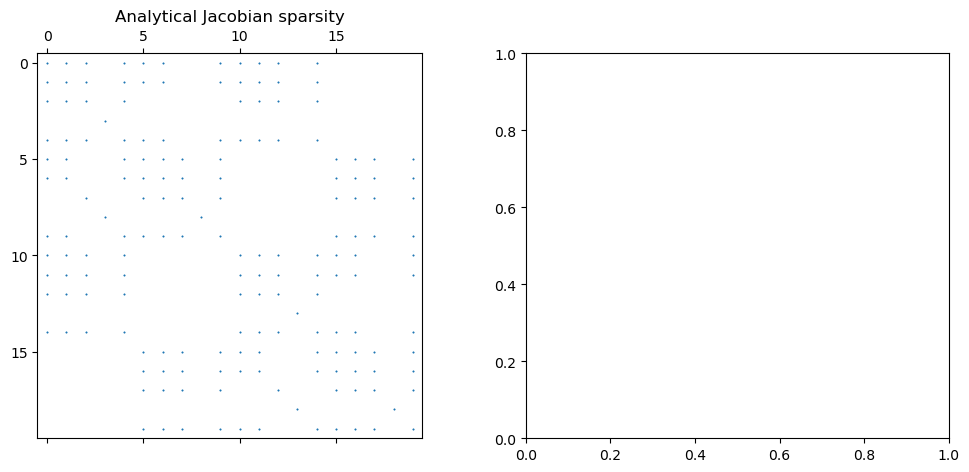

In [32]:
# sparsity pattern check 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#.spy to plot the sparsity pattern of a 2D array
axes[0].spy(J_slip, markersize=0.5)
axes[0].set_title('Analytical Jacobian sparsity')
plt.show()

4. Check by finite difference of vector multiplication 
J * q = (F(U+q*eps) -F(U))/eps

- randomly generate a vector q with shape (5N,)
- compute J * q 

- create a function that assemble the residual vector with shape (5N,)
- compute (F(U+q*eps) -F(U))/eps

- compare the two results

Errors at the boundary could be neglected --> it is a frozen ghost node problem 

Two test cases
- one uniform flow --> rel error for node 4 (interor): 3.0035e-08
- one uniform flow + 1% random pertubation --> rel error for node 4 (interor):  1.5483e-02

In [33]:
# ── 2D 3×3 grid — 9 nodes, 1 interior node ───────────────────────────────────
#  
#  Node layout (spacing Δx=Δy=1):
#
#   6---7---8      ← top boundary    (y=2)
#   |   |   |
#   3---4---5      ← interior row    (y=1)   node 4 = only interior node
#   |   |   |
#   0---1---2      ← bottom boundary (y=0)
#   x=0 x=1 x=2
#
#  Node types:
#   Corner (4): nodes 0,2,6,8  → 2 boundary faces each
#   Edge   (4): nodes 1,3,5,7  → 1 boundary face each
#   Interior(1): node 4         → 0 boundary faces  ← golden check

gamma = 1.4
R_gas = 287.0

rho0  = 1.225
u0    = 68.0525
p0    = 101325.0
T0_bc = p0 / (rho0 * R_gas)
E0    = p0 / ((gamma-1)*rho0) + 0.5*u0**2
U0    = np.array([rho0, rho0*u0, 0.0, 0.0, rho0*E0])

N_3x3 = 9
np.random.seed(7)
U_list_3x3  = np.tile(U0, (N_3x3, 1))
# U_list_3x3 += 0.01 * U0 * np.random.randn(N_3x3, 5)   # small per-node perturbation

# ── Coordinates ───────────────────────────────────────────────────────────────
coord_3x3 = np.array([
    [0., 0., 0.],  # 0
    [1., 0., 0.],  # 1
    [2., 0., 0.],  # 2
    [0., 1., 0.],  # 3
    [1., 1., 0.],  # 4  ← interior
    [2., 1., 0.],  # 5
    [0., 2., 0.],  # 6
    [1., 2., 0.],  # 7
    [2., 2., 0.],  # 8
])

# ── Interior faces ─────────────────────────────────────────────────────────────
# [i(1-based), j(1-based), Ax, Ay, Az]
# Horizontal edges: normal +x, area = 1.0
# Vertical edges:   normal +y, area = 1.0
fortfile_3x3 = np.array([
    # horizontal edges (normal in +x)
    [1, 2,  1., 0., 0., 1],   # 0→1
    [2, 3,  1., 0., 0., 1],   # 1→2
    [4, 5,  1., 0., 0., 1],   # 3→4
    [5, 6,  1., 0., 0., 1],   # 4→5
    [7, 8,  1., 0., 0., 1],   # 6→7
    [8, 9,  1., 0., 0., 1],   # 7→8
    # vertical edges (normal in +y)
    [1, 4,  0., 1., 0., 1],   # 0→3
    [2, 5,  0., 1., 0., 1],   # 1→4
    [3, 6,  0., 1., 0., 1],   # 2→5
    [4, 7,  0., 1., 0., 1],   # 3→6
    [5, 8,  0., 1., 0., 1],   # 4→7
    [6, 9,  0., 1., 0., 1],   # 5→8
], dtype=float)

# ── Boundary faces ─────────────────────────────────────────────────────────────
# Corner nodes  → area = 0.5 per boundary side
# Edge BC nodes → area = 1.0
# [node(1-based), Ax, Ay, Az, ds, bc_type, u_b, v_b, w_b, T_b, P_b, flag]
r = 0    # riemann bc_type
s = 1    # slip    bc_type
ns = 2   # noslip    bc_type
boundary_list_3x3 = np.array([
    # ── Left boundary (x=0) riemann inflow ────────────────────────────────────
    [1,  -0.5, 0., 0.,  1., r, u0, 0., 0., T0_bc, p0, 1],  # node 0 corner
    [4,  -1.0, 0., 0.,  1., r, u0, 0., 0., T0_bc, p0, 1],  # node 3 edge
    [7,  -0.5, 0., 0.,  1., r, u0, 0., 0., T0_bc, p0, 1],  # node 6 corner
    # ── Right boundary (x=2) riemann outflow ──────────────────────────────────
    [3,   0.5, 0., 0.,  1., r, u0, 0., 0., T0_bc, p0, 2],  # node 2 corner
    [6,   1.0, 0., 0.,  1., r, u0, 0., 0., T0_bc, p0, 2],  # node 5 edge
    [9,   0.5, 0., 0.,  1., r, u0, 0., 0., T0_bc, p0, 2],  # node 8 corner
    # ── Bottom boundary (y=0) slip ────────────────────────────────────────────
    [1,   0., -0.5, 0., 1., ns, 0., 0., 0., T0_bc, p0, 3],  # node 0 corner
    [2,   0., -1.0, 0., 1., ns, 0., 0., 0., T0_bc, p0, 3],  # node 1 edge
    [3,   0., -0.5, 0., 1., ns, 0., 0., 0., T0_bc, p0, 3],  # node 2 corner
    # ── Top boundary (y=2) slip ───────────────────────────────────────────────
    [7,   0.,  0.5, 0., 1., ns, 0., 0., 0., T0_bc, p0, 4],  # node 6 corner
    [8,   0.,  1.0, 0., 1., ns, 0., 0., 0., T0_bc, p0, 4],  # node 7 edge
    [9,   0.,  0.5, 0., 1., ns, 0., 0., 0., T0_bc, p0, 4],  # node 8 corner
    # node 4 (interior) → no entry
], dtype=float)

# ── Assemble analytical Jacobian ──────────────────────────────────────────────
J_anal_3x3 = assemble_global_jacobian_fd(
    fortfile_3x3, U_list_3x3, coord_3x3, boundary_list_3x3,
    gamma=gamma, R_gas=R_gas
)   # (45, 45)

# ── JV product verification ───────────────────────────────────────────────────
eps    = 1e-8
np.random.seed(42)
q_full = np.random.randn(5 * N_3x3)   # (45,) fully random

U_flat = U_list_3x3.flatten()

R0     = assemble_residual(fortfile_3x3, U_list_3x3, coord_3x3,
                            boundary_list_3x3, gamma=gamma, R_gas=R_gas)
R_pert = assemble_residual(fortfile_3x3,
                            (U_flat + eps * q_full).reshape(-1, 5),
                            coord_3x3, boundary_list_3x3,
                            gamma=gamma, R_gas=R_gas)

jv_fd   = (R_pert - R0) / eps
jv_anal = J_anal_3x3 @ q_full

# ── Global error ──────────────────────────────────────────────────────────────
rel_err = np.linalg.norm(jv_fd - jv_anal) / (np.linalg.norm(jv_fd) + 1e-14)
print(f"3×3 JV product relative error (global): {rel_err:.4e}")
print(f"  ||jv_fd||   = {np.linalg.norm(jv_fd):.6e}")
print(f"  ||jv_anal|| = {np.linalg.norm(jv_anal):.6e}")

# ── Per-node breakdown ────────────────────────────────────────────────────────
node_type = [
    'corner BC', 'edge BC',   'corner BC',
    'edge BC',   'INTERIOR',  'edge BC',
    'corner BC', 'edge BC',   'corner BC',
]

print(f"\n{'Node':<5} {'Type':<12} {'||jv_fd||':>12} {'||jv_anal||':>12} {'rel_err':>12}")
for k in range(N_3x3):
    fd_k  = jv_fd  [5*k:5*k+5]
    an_k  = jv_anal[5*k:5*k+5]
    err_k = np.linalg.norm(fd_k - an_k) / (np.linalg.norm(fd_k) + 1e-14)
    flag  = '  ← CHECK' if k == 4 else ''
    print(f"{k:<5} {node_type[k]:<12} "
          f"{np.linalg.norm(fd_k):>12.4e} "
          f"{np.linalg.norm(an_k):>12.4e} "
          f"{err_k:>12.4e}{flag}")

# ── Interior node isolated check (node 4) ─────────────────────────────────────
print(f"\n── Interior node (node 4) isolated ──")
fd_int   = jv_fd  [5*4:5*4+5]
an_int   = jv_anal[5*4:5*4+5]
err_int  = np.linalg.norm(fd_int - an_int) / (np.linalg.norm(fd_int) + 1e-14)
print(f"  ||jv_fd||   = {np.linalg.norm(fd_int):.6e}")
print(f"  ||jv_anal|| = {np.linalg.norm(an_int):.6e}")
print(f"  rel_err     = {err_int:.4e}   ← target < 1e-4")

var_names = ['rho', 'rhou', 'rhov', 'rhow', 'rhoE']
print(f"\n  {'DOF':<6} {'jv_fd':>14} {'jv_anal':>14} {'abs_err':>12}")
for d, name in enumerate(var_names):
    print(f"  {name:<6} {fd_int[d]:>14.4e} {an_int[d]:>14.4e} "
          f"{abs(fd_int[d]-an_int[d]):>12.4e}")

Volumes from col 5 (directly extracted from node i ) : 8
Volumes from geometry (by geometric approxmiation for missing j-nodes): 1
3×3 JV product relative error (global): 1.0636e-06
  ||jv_fd||   = 8.990193e+07
  ||jv_anal|| = 8.990201e+07

Node  Type            ||jv_fd||  ||jv_anal||      rel_err
0     corner BC      4.7066e+06   4.7066e+06   2.1362e-06
1     edge BC        1.0141e+07   1.0141e+07   6.2186e-08
2     corner BC      3.6341e+07   3.6341e+07   1.2606e-06
3     edge BC        2.4357e+06   2.4357e+06   1.0160e-05
4     INTERIOR       1.3017e+07   1.3017e+07   3.0035e-08  ← CHECK
5     edge BC        1.8128e+06   1.8128e+06   1.1990e-05
6     corner BC      1.8307e+07   1.8307e+07   5.7670e-07
7     edge BC        8.4408e+06   8.4408e+06   9.2538e-08
8     corner BC      7.7792e+07   7.7792e+07   9.7443e-07

── Interior node (node 4) isolated ──
  ||jv_fd||   = 1.301715e+07
  ||jv_anal|| = 1.301715e+07
  rel_err     = 3.0035e-08   ← target < 1e-4

  DOF             jv_fd    